# 01 — Exploration

Two independent checks before running the main queries:

**Part A — GDELT DOC 2.0 API (no credentials, free)**  
Fetch a quick monthly volume time series to confirm the topic is tractable and to cross-validate BigQuery results later.

**Part B — BigQuery schema validation (requires credentials)**  
Confirm that `AllNames` and `Quotations` fields actually contain the keywords we expect, inspect which `V2Themes` codes co-occur with AI entity mentions, and estimate scan size before running `aggregate_frames.sql`.

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..')))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

---
## Part A — DOC 2.0 API (no credentials needed)

In [3]:
from src.doc_api import fetch_timeline_vol, fetch_timeline_tone, build_doc_query

query = build_doc_query()
print('Query:', query)

Query: (chatgpt OR "generative ai" OR "large language model" OR openai OR gemini OR "stable diffusion" OR midjourney OR "foundation model") (regulation OR governance OR policy OR oversight OR "ai act" OR "ai safety" OR privacy OR "data protection")


In [4]:
vol_api = fetch_timeline_vol(
    query=query,
    start='20221101000000',
    end='20260601000000',
)
print(f'Received {len(vol_api)} monthly data points')
vol_api.head()

Rate limited (429); retrying in 10s …
Received 44 monthly data points


/home/Brewen/cwd/tud/GenAI-GDELT/notebooks/../src/doc_api.py:118: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["date"].dt.to_period("M")


,month,volume
0,2022-11,542
1,2022-12,1066
2,2023-01,1985
3,2023-02,4086
4,2023-03,4813


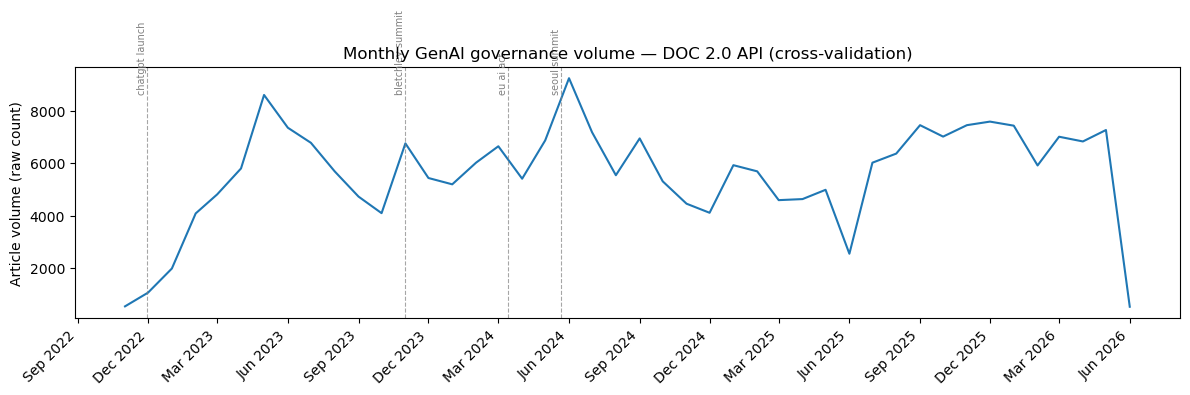

In [5]:
from src.dictionaries import MILESTONES

fig, ax = plt.subplots(figsize=(12, 4))
dates = vol_api['month'].dt.to_timestamp()
ax.plot(dates, vol_api['volume'], linewidth=1.5)

for m in MILESTONES:
    ts = pd.Timestamp(m['date'])
    ax.axvline(ts, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.text(ts, ax.get_ylim()[1] * 0.9, m['name'].replace('_', ' '),
            rotation=90, fontsize=7, ha='right', color='grey')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
ax.set_title('Monthly GenAI governance volume — DOC 2.0 API (cross-validation)')
ax.set_ylabel('Article volume (raw count)')
plt.tight_layout()
plt.show()

/home/Brewen/cwd/tud/GenAI-GDELT/notebooks/../src/doc_api.py:154: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["date"].dt.to_period("M")


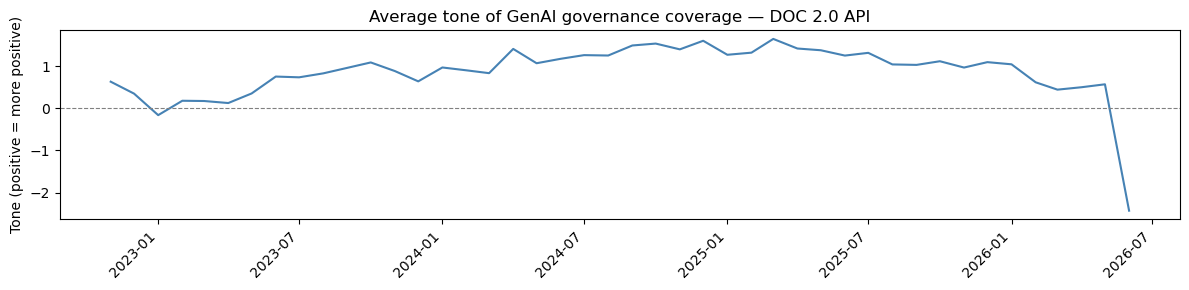

In [7]:
# Optional: fetch tone over time
tone_api = fetch_timeline_tone(query=query, start='20221101000000', end='20260601000000')

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(tone_api['month'].dt.to_timestamp(), tone_api['tone'], color='steelblue')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Average tone of GenAI governance coverage — DOC 2.0 API')
ax.set_ylabel('Tone (positive = more positive)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## Part B — BigQuery schema validation

Run these cells after completing the credential setup in `docs/credentials_setup.md`.

In [1]:
import os
from google.cloud import bigquery

PROJECT = os.environ.get('BIGQUERY_PROJECT', 'YOUR_PROJECT_ID')
client = bigquery.Client(project=PROJECT)
print('Connected:', PROJECT)

Connected: genai-gdelt


In [3]:
# Check scan size of aggregate_frames.sql before running it
# Paste the query and BigQuery will show bytes to be scanned without executing

# Quick low-cost schema check (~2 GB)
schema_sql = """
SELECT
  DATE,
  SourceCommonName,
  LEFT(AllNames, 300)   AS AllNames_preview,
  LEFT(Quotations, 400) AS Quotations_preview,
  LEFT(V2Themes, 200)   AS V2Themes_preview,
  V2Tone
FROM `gdelt-bq.gdeltv2.gkg_partitioned`
WHERE DATE(_PARTITIONTIME) = '2023-01-15'
  AND LOWER(AllNames) LIKE '%chatgpt%'
LIMIT 10
"""
sample = client.query(schema_sql).to_dataframe()
sample

,DATE,SourceCommonName,AllNames_preview,Quotations_preview,V2Themes_preview,V2Tone
0,20230115073000,ladepeche.fr,"Emily Bender,994;Chatgpt Takes,1383;Galactica ...",NaN,"TAX_FNCACT_GUIDE,5007;TAX_DISEASE_COMA,6487;TA...","0.0878734622144113,2.28471001757469,2.19683655..."
1,20230115190000,irozhlas.cz,"Ban Or Start,54;The New York City,238;Applicat...",NaN,"BAN,44;BAN,249;BAN,1086;BAN,1738;BAN,1860;WB_1...","-0.99009900990099,2.97029702970297,3.960396039..."
2,20230115010000,haqqin.az,"New Over,14;New Over,93;Indo Europeans,229;New...",NaN,"TAX_FNCACT_ASSISTANT,16114;EPU_CATS_NATIONAL_S...","-0.557742782152231,3.1496062992126,3.707349081..."
3,20230115010000,inosmi.ru,"Teachers Are Worried,26;Teachers Have,773;Iron...",NaN,"TAX_FNCACT_ASSISTANT,5753;UNGP_JOB_OPPORTUNITI...","-1.00071479628306,2.82344531808435,3.824160114..."


In [4]:
# Top V2Themes codes co-occurring with ChatGPT mentions
# Helps identify governance-relevant theme codes to add to the SQL filter
themes_sql = """
SELECT theme, COUNT(*) AS n
FROM `gdelt-bq.gdeltv2.gkg_partitioned`,
  UNNEST(SPLIT(V2Themes, ';')) AS theme
WHERE DATE(_PARTITIONTIME) >= '2023-01-01'
  AND DATE(_PARTITIONTIME) <  '2023-07-01'
  AND LOWER(AllNames) LIKE '%chatgpt%'
  AND theme != ''
GROUP BY theme
ORDER BY n DESC
LIMIT 50
"""
themes_df = client.query(themes_sql).to_dataframe()
themes_df.head(30)

,theme,n
0,"CRISISLEX_CRISISLEXREC,34",15
1,"CRISISLEX_CRISISLEXREC,47",13
2,"TAX_FNCACT_BARD,5",11
3,"WB_694_BROADCAST_AND_MEDIA,17",8
4,"MEDIA_MSM,17",8
5,WB_133_INFORMATION_AND_COMMUNICATION_TECHNOLOG...,8
6,"WB_678_DIGITAL_GOVERNMENT,17",8
7,"WB_1986_MOUNTAINS,60",7
8,"WB_435_AGRICULTURE_AND_FOOD_SECURITY,60",7
9,"WB_1979_NATURAL_RESOURCE_MANAGEMENT,60",7


In [5]:
# Dry-run aggregate_frames.sql to see bytes scanned before executing
agg_sql = open('../queries/aggregate_frames.sql').read()

job_config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
dry = client.query(agg_sql, job_config=job_config)
gb = dry.total_bytes_processed / 1e9
print(f'aggregate_frames.sql would scan {gb:.1f} GB  ({gb/1000:.2f} TB)')
print('Free tier: 1 TB/month — this query is', 'SAFE' if gb < 900 else 'CLOSE TO LIMIT')

aggregate_frames.sql would scan 582.4 GB  (0.58 TB)
Free tier: 1 TB/month — this query is SAFE
